<a href="https://colab.research.google.com/github/Gloou-ui/NM/blob/main/%D0%9B%D0%912_%D0%9B%D0%B8%D1%82%D0%B2%D0%B8%D0%BD_%D0%9C%D0%B8%D1%80%D0%BE%D1%81%D0%BB%D0%B0%D0%B2_%D0%A4%D0%86%D0%A23_10_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"

headers = {
    "User-Agent": "MiterX/5.0"
}

response = requests.get(url, headers=headers)
response.raise_for_status()

tables = pd.read_html(response.text)

df = next(
    table for table in tables
    if "Country/Territory" in table.columns
)

print(df.head())
print(df.columns)

  Country/Territory IMF (2026)[1] World Bank (2025)[6]  \
0             World     126295331            118350166   
1     United States      32383920             30769700   
2        China[n 1]      20851593             19498039   
3           Germany       5452858              5050923   
4             Japan       4379253              4435163   

  United Nations (2024)[7]  
0                111565144  
1                 29298000  
2                 18743802  
3                  4659929  
4                  4026211  
Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')


/tmp/ipykernel_867/357898607.py:16: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


# Завдання 1

Був присутнім на парах

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [ ]:
print(df.columns)

Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')


In [ ]:
print(df.head())

  Country/Territory IMF (2026)[1] World Bank (2025)[6]  \
0             World     126295331            118350166   
1     United States      32383920             30769700   
2        China[n 1]      20851593             19498039   
3           Germany       5452858              5050923   
4             Japan       4379253              4435163   

  United Nations (2024)[7]  
0                111565144  
1                 29298000  
2                 18743802  
3                  4659929  
4                  4026211  


2.	Визначити розмір датасета.

In [ ]:
print(df.shape)

(222, 4)


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [4]:
df = df.iloc[:, :4]

df.columns = [
    'Country/Territory',
    'IMF (2026)',
    'World Bank (2025)',
    'United Nations (2024)'
]

df = df[df['Country/Territory'] != 'World']

print(df.head())
print(df.shape)

  Country/Territory IMF (2026) World Bank (2025) United Nations (2024)
1     United States   32383920          30769700              29298000
2        China[n 1]   20851593          19498039              18743802
3           Germany    5452858           5050923               4659929
4             Japan    4379253           4435163               4026211
5    United Kingdom    4264794           4002588               3685881
(221, 4)


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [5]:
df = df.replace('—', np.nan)

columns = [
    'IMF (2026)',
    'World Bank (2025)',
    'United Nations (2024)'
]

for column in columns:
    df[column] = (
        df[column]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace(r'\s*\([^)]*\)', '', regex=True)
    )
    df[column] = pd.to_numeric(df[column], errors='coerce')

print("Пропуски до заповнення:")
print(df.isna().sum())

for column in columns:
    df[column] = df[column].fillna(df[column].mean())

print("Пропуски після заповнення:")
print(df.isna().sum())

Пропуски до заповнення:
Country/Territory         0
IMF (2026)               24
World Bank (2025)         7
United Nations (2024)     9
dtype: int64
Пропуски після заповнення:
Country/Territory        0
IMF (2026)               0
World Bank (2025)        0
United Nations (2024)    0
dtype: int64


5. Ще раз вивести датасет

In [6]:
print(df)

    Country/Territory    IMF (2026)  World Bank (2025)  United Nations (2024)
1       United States  3.238392e+07       3.076970e+07             29298000.0
2          China[n 1]  2.085159e+07       1.949804e+07             18743802.0
3             Germany  5.452858e+06       5.050923e+06              4659929.0
4               Japan  4.379253e+06       4.435163e+06              4026211.0
5      United Kingdom  4.264794e+06       4.002588e+06              3685881.0
..                ...           ...                ...                    ...
217             Palau  3.770000e+02       3.450000e+02                  310.0
218  Marshall Islands  3.420000e+02       3.080000e+02                  281.0
219             Nauru  1.960000e+02       1.760000e+02                  187.0
220        Montserrat  6.412000e+05       5.482661e+05                   81.0
221            Tuvalu  6.500000e+01       5.700000e+01                   56.0

[221 rows x 4 columns]


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [7]:
print("Кількість дублікатів:", df.duplicated().sum())

df = df.drop_duplicates()

print("Кількість дублікатів після видалення:", df.duplicated().sum())

Кількість дублікатів: 0
Кількість дублікатів після видалення: 0


7.	Вивести описову статистику датасету describe()

In [8]:
print(df.describe())

         IMF (2026)  World Bank (2025)  United Nations (2024)
count  2.210000e+02       2.210000e+02           2.210000e+02
mean   6.412000e+05       5.482661e+05           5.224912e+05
std    2.668734e+06       2.528406e+06           2.410079e+06
min    6.500000e+01       5.700000e+01           5.600000e+01
25%    1.733600e+04       9.194000e+03           8.840000e+03
50%    8.383200e+04       4.549000e+04           4.276500e+04
75%    5.799960e+05       3.062390e+05           2.986970e+05
max    3.238392e+07       3.076970e+07           2.929800e+07


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [9]:
df['Difference'] = df['IMF (2026)'] - df['World Bank (2025)']

print(
    df[
        ['Country/Territory',
         'IMF (2026)',
         'World Bank (2025)',
         'Difference']
    ]
)

    Country/Territory    IMF (2026)  World Bank (2025)    Difference
1       United States  3.238392e+07       3.076970e+07  1.614220e+06
2          China[n 1]  2.085159e+07       1.949804e+07  1.353554e+06
3             Germany  5.452858e+06       5.050923e+06  4.019350e+05
4               Japan  4.379253e+06       4.435163e+06 -5.591000e+04
5      United Kingdom  4.264794e+06       4.002588e+06  2.622060e+05
..                ...           ...                ...           ...
217             Palau  3.770000e+02       3.450000e+02  3.200000e+01
218  Marshall Islands  3.420000e+02       3.080000e+02  3.400000e+01
219             Nauru  1.960000e+02       1.760000e+02  2.000000e+01
220        Montserrat  6.412000e+05       5.482661e+05  9.293397e+04
221            Tuvalu  6.500000e+01       5.700000e+01  8.000000e+00

[221 rows x 4 columns]


In [10]:
top_difference = df.loc[
    df['Difference'].abs().nlargest(10).index,
    ['Country/Territory', 'Difference']
]

print(top_difference)

            Country/Territory    Difference
1               United States  1.614220e+06
2                  China[n 1]  1.353554e+06
212              Saint Martin  6.405510e+05
209            American Samoa  6.403290e+05
208  Northern Mariana Islands  6.401040e+05
201  Turks and Caicos Islands  6.394550e+05
197              Sint Maarten  6.393120e+05
184                 Greenland  6.378730e+05
182                   Curaçao  6.376390e+05
180             Faroe Islands  6.371470e+05


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [11]:
columns = [
    'IMF (2026)',
    'World Bank (2025)',
    'United Nations (2024)'
]

correlation = df[columns].corr()

print(correlation)

                       IMF (2026)  World Bank (2025)  United Nations (2024)
IMF (2026)               1.000000           0.997809               0.998046
World Bank (2025)        0.997809           1.000000               0.998378
United Nations (2024)    0.998046           0.998378               1.000000


In [12]:
pairs = correlation.where(
    np.triu(np.ones(correlation.shape), k=1).astype(bool)
).stack().sort_values(ascending=False)

print(pairs)

World Bank (2025)  United Nations (2024)    0.998378
IMF (2026)         United Nations (2024)    0.998046
                   World Bank (2025)        0.997809
dtype: float64


Обчислити середнє значення за стовпцями

In [13]:
print(df[columns].mean())

IMF (2026)               641200.030457
World Bank (2025)        548266.060748
United Nations (2024)    522491.207547
dtype: float64


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [14]:
df['Standard deviation'] = df[columns].std(axis=1)

print(
    df[
        ['Country/Territory', 'Standard deviation']
    ]
)
result = df.loc[
    df['Standard deviation'].idxmax(),
    ['Country/Territory', 'Standard deviation']
]

print("Найбільша варіативність:")
print(result)

    Country/Territory  Standard deviation
1       United States        1.543508e+06
2          China[n 1]        1.068002e+06
3             Germany        3.964771e+05
4               Japan        2.217380e+05
5      United Kingdom        2.898838e+05
..                ...                 ...
217             Palau        3.351119e+01
218  Marshall Islands        3.056687e+01
219             Nauru        1.001665e+01
220        Montserrat        3.464528e+05
221            Tuvalu        4.932883e+00

[221 rows x 2 columns]
Найбільша варіативність:
Country/Territory      United States
Standard deviation    1543508.414014
Name: 1, dtype: object


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [15]:
for column in columns:
    max_index = df[column].idxmax()
    min_index = df[column].idxmin()

    print("\n", column)

    print(
        "Найвище:",
        df.loc[max_index, 'Country/Territory'],
        df.loc[max_index, column]
    )

    print(
        "Найнижче:",
        df.loc[min_index, 'Country/Territory'],
        df.loc[min_index, column]
    )


 IMF (2026)
Найвище: United States 32383920.0
Найнижче: Tuvalu 65.0

 World Bank (2025)
Найвище: United States 30769700.0
Найнижче: Tuvalu 57.0

 United Nations (2024)
Найвище: United States 29298000.0
Найнижче: Tuvalu 56.0


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

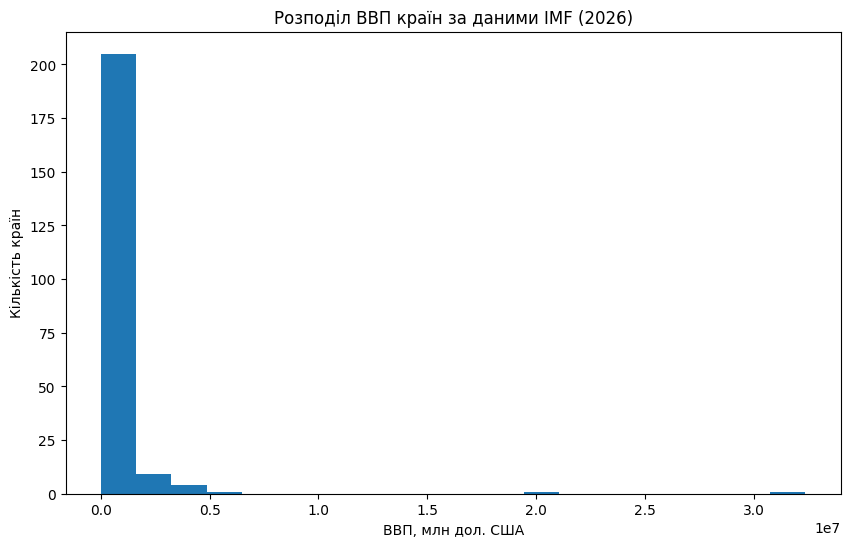

   Country/Territory  IMF (2026)
1      United States  32383920.0
2         China[n 1]  20851593.0
3            Germany   5452858.0
4              Japan   4379253.0
5     United Kingdom   4264794.0
6              India   4153191.0
7             France   3596094.0
8              Italy   2738164.0
9             Russia   2656452.0
10            Brazil   2635912.0


In [17]:
plt.figure(figsize=(10, 6))

plt.hist(df['IMF (2026)'], bins=20)

plt.xlabel('ВВП, млн дол. США')
plt.ylabel('Кількість країн')
plt.title('Розподіл ВВП країн за даними IMF (2026)')

plt.show()
print(
    df.nlargest(
        10,
        'IMF (2026)'
    )[
        ['Country/Territory', 'IMF (2026)']
    ]
)

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [18]:
for column in columns:
    df[column + ' Share'] = (
        df[column] / df[column].sum() * 100
    )

print(
    df[
        ['Country/Territory',
         'IMF (2026) Share',
         'World Bank (2025) Share',
         'United Nations (2024) Share']
    ]
)
for column in columns:
    share_column = column + ' Share'

    print("\n", column)

    print(
        df.nlargest(10, share_column)[
            ['Country/Territory', share_column]
        ]
    )

    Country/Territory  IMF (2026) Share  World Bank (2025) Share  \
1       United States         22.853021                25.394498   
2          China[n 1]         14.714768                16.091899   
3             Germany          3.848029                 4.168570   
4               Japan          3.090397                 3.660378   
5      United Kingdom          3.009624                 3.303370   
..                ...               ...                      ...   
217             Palau          0.000266                 0.000285   
218  Marshall Islands          0.000241                 0.000254   
219             Nauru          0.000138                 0.000145   
220        Montserrat          0.452489                 0.452489   
221            Tuvalu          0.000046                 0.000047   

     United Nations (2024) Share  
1                      25.372702  
2                      16.232538  
3                       4.035599  
4                       3.486786  
5       

15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

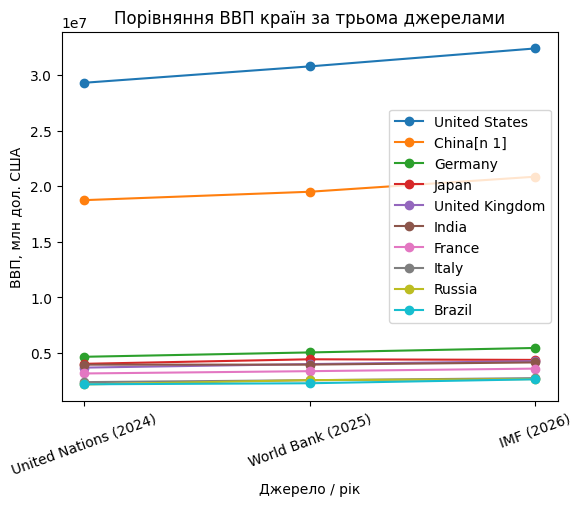

In [19]:
top10 = df.nlargest(10, 'IMF (2026)')

for _, row in top10.iterrows():
    plt.plot(
        ['United Nations (2024)',
         'World Bank (2025)',
         'IMF (2026)'],
        [
            row['United Nations (2024)'],
            row['World Bank (2025)'],
            row['IMF (2026)']
        ],
        marker='o',
        label=row['Country/Territory']
    )

plt.xlabel('Джерело / рік')
plt.ylabel('ВВП, млн дол. США')
plt.title('Порівняння ВВП країн за трьома джерелами')
plt.xticks(rotation=20)
plt.legend()
plt.show()

In [20]:
growth = df[
    (df['United Nations (2024)'] < df['World Bank (2025)']) &
    (df['World Bank (2025)'] < df['IMF (2026)'])
]

print(
    growth[
        ['Country/Territory'] + columns
    ]
)

    Country/Territory    IMF (2026)  World Bank (2025)  United Nations (2024)
1       United States  3.238392e+07       3.076970e+07             29298000.0
2          China[n 1]  2.085159e+07       1.949804e+07             18743802.0
3             Germany  5.452858e+06       5.050923e+06              4659929.0
5      United Kingdom  4.264794e+06       4.002588e+06              3685881.0
6               India  4.153191e+06       3.956067e+06              3952244.0
..                ...           ...                ...                    ...
216          Kiribati  4.010000e+02       3.490000e+02                  343.0
217             Palau  3.770000e+02       3.450000e+02                  310.0
218  Marshall Islands  3.420000e+02       3.080000e+02                  281.0
220        Montserrat  6.412000e+05       5.482661e+05                   81.0
221            Tuvalu  6.500000e+01       5.700000e+01                   56.0

[170 rows x 4 columns]


In [21]:
decline = df[
    (df['United Nations (2024)'] > df['World Bank (2025)']) &
    (df['World Bank (2025)'] > df['IMF (2026)'])
]

print(
    decline[
        ['Country/Territory'] + columns
    ]
)

   Country/Territory  IMF (2026)  World Bank (2025)  United Nations (2024)
53              Iran    300293.0           362682.0               448092.0
72          Ethiopia    121527.0           126359.0               142275.0
